In [3]:
import matplotlib.pyplot as plt
import pandas as pd


In [4]:
df=pd.read_csv('athlete_data.csv')


In [5]:
df_made=df[df['Gender']=='Female' ].groupby('Gender')['Injury_Indicator'].value_counts().reset_index()
df_made2=df[df['Gender']=='Male' ].groupby('Gender')['Injury_Indicator'].value_counts().reset_index()

df_made2

,Gender,Injury_Indicator,count
0,Male,No,138
1,Male,Yes,130


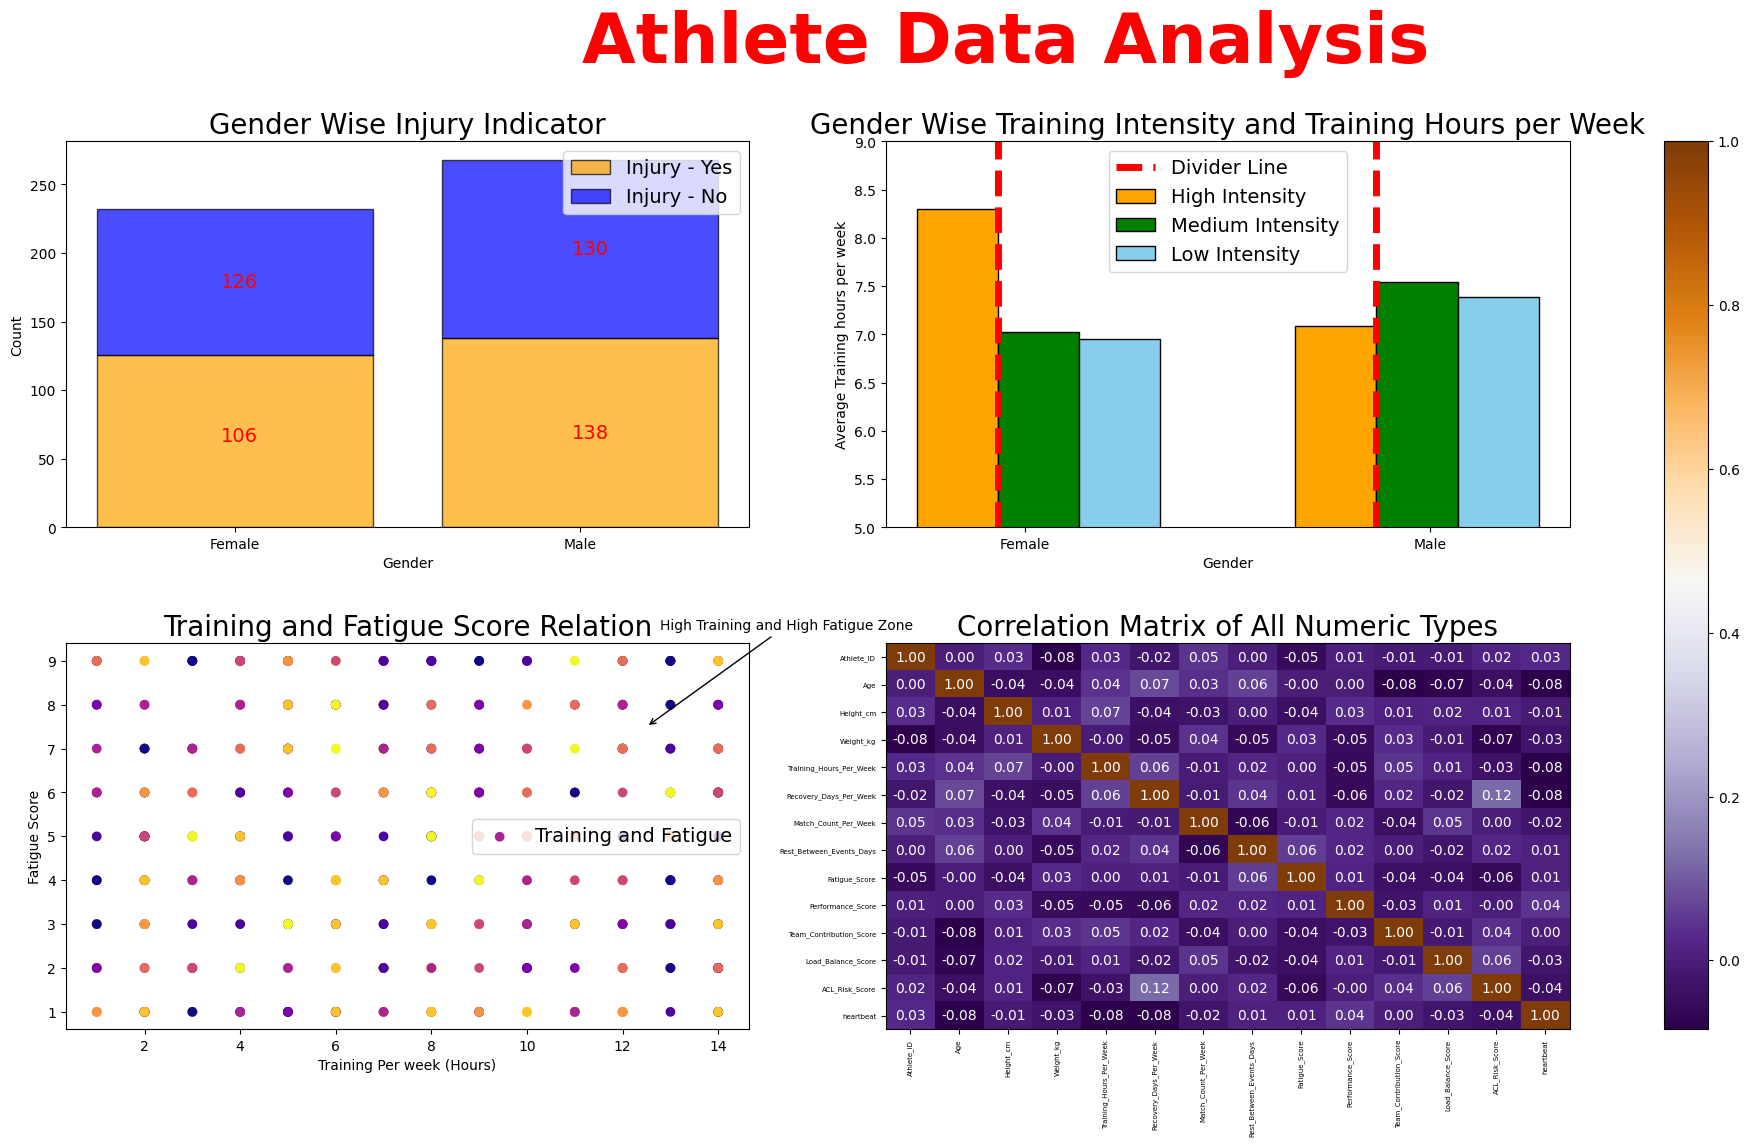

In [6]:


fig,ax=plt.subplots(2,2,figsize=(20,12))
fig.suptitle('Athlete Data Analysis',color='red',fontsize=50,fontweight='bold')
plt.subplots_adjust(left=0.03,right=0.97,top=0.87,bottom=0.13,hspace=0.3,wspace=0.2)

ax[0,0].bar(df_made.loc[0,'Gender'],df_made.loc[0,'count'],edgecolor='black',color='orange',alpha=0.7,label='Injury - Yes')
ax[0,0].bar(df_made.loc[1,'Gender'],df_made.loc[1,'count'],edgecolor='black',color='blue',alpha=0.7,label='Injury - No',bottom=df_made.loc[0,'count'])
ax[0,0].bar(df_made2.loc[0,'Gender'],df_made2.loc[0,'count'],edgecolor='black',color='orange',alpha=0.7)
ax[0,0].bar(df_made2.loc[1,'Gender'],df_made2.loc[1,'count'],edgecolor='black',color='blue',alpha=0.7,bottom=df_made2.loc[0,'count'])
ax[0,0].legend(fontsize=14)
ax[0,0].annotate(df_made.loc[0,'count'],xy=(-0.04,175),fontsize=14,color='red')
ax[0,0].annotate(df_made.loc[1,'count'],xy=(-0.04,62.5),fontsize=14,color='red')
ax[0,0].annotate(df_made2.loc[0,'count'],xy=(0.975,130/2),fontsize=14,color='red')
ax[0,0].annotate(df_made2.loc[1,'count'],xy=(0.975,130+(138/2)),fontsize=14,color='red')
ax[0,0].set_xlabel('Gender')
ax[0,0].set_ylabel('Count')
ax[0,0].set_title('Gender Wise Injury Indicator',fontsize=20)

df_women=df[df['Gender']=="Female"].groupby(['Gender','Training_Intensity'])['Training_Hours_Per_Week'].mean().reset_index()
df_men=df[df['Gender']=="Male"].groupby(['Gender','Training_Intensity'])['Training_Hours_Per_Week'].mean().reset_index()
ax[0,1].bar(1,df_women.loc[0,'Training_Hours_Per_Week'],color='orange',edgecolor='black',width=0.3,label='High Intensity')
ax[0,1].bar(1.3,df_women.loc[2,'Training_Hours_Per_Week'],color='green',edgecolor='black',width=0.3,label='Medium Intensity')
ax[0,1].bar(1.6,df_women.loc[1,'Training_Hours_Per_Week'],color='skyblue',edgecolor='black',width=0.3,label='Low Intensity')
ax[0,1].bar(2.4,df_men.loc[0,'Training_Hours_Per_Week'],color='orange',edgecolor='black',width=0.3)
ax[0,1].bar(2.7,df_men.loc[2,'Training_Hours_Per_Week'],color='green',edgecolor='black',width=0.3)
ax[0,1].bar(3,df_men.loc[1,'Training_Hours_Per_Week'],color='skyblue',edgecolor='black',width=0.3)
ax[0,1].set_xticks([1.25,2.75],labels=['Female','Male'])
ax[0,1].axvline(x=1.15,color='red',linestyle='--',linewidth=5,label='Divider Line')
ax[0,1].axvline(x=2.55,color='red',linestyle='--',linewidth=5)
ax[0,1].legend(fontsize=14)
ax[0,1].set_ylim((5,9))
ax[0,1].set_xlabel('Gender')
ax[0,1].set_ylabel('Average Training hours per week')
ax[0,1].set_title('Gender Wise Training Intensity and Training Hours per Week',fontsize=20)

scatter=ax[1,0].scatter(df['Training_Hours_Per_Week'],df['Fatigue_Score'],cmap='plasma',c=df['ACL_Risk_Score'],label='Training and Fatigue')
ax[1,0].annotate("High Training and High Fatigue Zone",xy=(df['Training_Hours_Per_Week'].max()-1.5,df['Fatigue_Score'].max()-1.5),xytext=(10,70),textcoords='offset points',arrowprops=dict(facecolor='black',arrowstyle='->'),fontsize=10)
ax[1,0].legend(fontsize=14)
ax[1,0].set_xlabel('Training Per week (Hours)')
ax[1,0].set_ylabel('Fatigue Score')
ax[1,0].set_title('Training and Fatigue Score Relation',fontsize=20)


Matrix=df.select_dtypes(include=int).corr()

Heatmap=ax[1,1].imshow(Matrix.values,cmap='PuOr_r',aspect='auto')
ax[1,1].set_yticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13],labels=Matrix.index,fontsize=5)
ax[1,1].set_xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13],labels=Matrix.columns,rotation=90,fontsize=5)
fig.colorbar(Heatmap,ax=ax)
for i in range(Matrix.shape[0]):
    for j in range(Matrix.shape[1]):
        ax[1,1].text(j,i,f'{Matrix.iloc[i,j]:.2f}',color='white',ha='center',va='center')

ax[1,1].set_title("Correlation Matrix of All Numeric Types",fontsize=20)
plt.savefig('Section2.jpg',dpi=300,bbox_inches='tight')